# "Hold TQQQ above the 200-day line" — 3x upside without 3x crashes? 🎢
### The Reddit-famous leverage rotation, finally tested through the crash its backtests never show

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2000 cohort survives?: Busted](https://img.shields.io/badge/2000_cohort_survives%3F-Busted-8b949e?style=flat-square)

There's a plan that gets reposted on r/LETFs every single week. It goes: *TQQQ* (a fund that moves **3x** the Nasdaq-100 every day) *makes you rich in bull markets but loses 99% in crashes. So just hold TQQQ while the market is above its 200-day average, and hide in cash below it. You keep the 3x rocket, you dodge the crater.* The backtest attached to the post is always spectacular — and it always starts in **2010**.

TQQQ was born in February 2010. The worst thing that ever happened to the Nasdaq — the 2000-02 dot-com collapse, **−83%** on the index itself — is simply *not in the data* those charts use. So we rebuilt a 3x fund from QQQ's own daily returns (it matches the real TQQQ day-by-day at correlation **0.999**), ran the exact rule from 1999, and let the missing decade vote.

> 📓 **Plain-language layer.** Want the t-stats, the matched random timers and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚙️ Every chart below is drawn by the code beside it from the cached market tape; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leverage_rotation_200sma import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    QQQ = data.qqq_returns(PX)
    RF = data.rf_daily(PX)
    SIM3 = data.sim3x_returns(QQQ, RF)
    TQQQ = data.tqqq_returns(PX)
    SIG = st.sma_signal(PX["QQQ"].dropna())
    CASH = RF.reindex(QQQ.index).ffill()
    ROT, NSW = st.rotation_returns(SIM3, CASH, SIG, cost_bps=5.0)
else:
    PX = QQQ = RF = SIM3 = TQQQ = SIG = CASH = ROT = None
    NSW = 0
print("real tape cached:", HAVE_REAL, "| rotation days:", (0 if ROT is None else len(ROT)),
      "| switches:", NSW)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '82b00d3939c8', 'start': '1999-12-22', 'end': '2026-06-30', 'years': 26.5, 'n_days': 6669, 'exposure_pct': 73.7, 'switches': 186, 'switches_yr': 7.0, 'val': {'corr': 0.9989, 'resid_pct': -0.04, 'rms_bps': 18.6, 'nav_ratio': 1.08, 'fee_pct': 2.5, 'n_days': 4119}, 'rot': (11.5, 50.9, 0.433, -95.14, 17.81), 'qqq': (9.0, 26.8, 0.384, -82.96, 9.77), 'sim3x': (-2.11, 80.4, 0.353, -99.98, 0.57), 'hac_rot_qqq': (4.67, 1.66), 'hac_rot_3x': (-2.5, -0.61), 'rt': {'avg_welch': 0.05, 'sd_welch': 0.37, 'seeds': 40, 'real_sharpe': 0.433, 'rand_sharpe': 0.314, 'beat_pct': 78, 'rand_cagr': -0.11}, 'cond': {'mean_above': 5.08, 'mean_below': 4.18, 't_mean': 0.14, 'vol_above': 19.8, 'vol_below': 40.4, 'ratio': 2.05, 't_var': 13.79}, 'costs': [(0, 11.89, 0.44, -95.1), (2, 11.73, 0.437, -95.1), (5, 11.5, 0.433, -95.1), (10, 11.1, 0.426, -95.2)], 'windows': [(150, 10.24, -98.6, 220, 1.37), (200, 11.5, -95.1, 186, 1.66), (250, 14.38, -86.9, 146, 2.11)], 'subs': [('dot-com 2000-03 -> 2002-10', -91.8, -92.3, -82.7, -83.0, -100.0, -100.0, 21), ('GFC 2007-10 -> 2009-03', -54.6, -56.6, -52.3, -53.4, -94.4, -94.6, 15), ('COVID 2020-02-19 -> 04-30', -41.5, -55.3, -6.5, -28.6, -38.5, -69.7, 4), ('2022 bear', -42.9, -45.6, -32.6, -34.8, -79.0, -80.9, 9), ('2020 full year', 100.9, -55.3, 48.4, -28.6, 111.4, -69.7, 4)], 'cohort': {'rotation': (507, -95.14, '2018-06-14', 18.2, 104982), 'qqq': (1729, -82.96, '2015-02-13', 14.9, 75338), 'tqqq': (2, -99.98, 'NEVER', None, 3349)}, 'real2010': {'rot': (33.3, 0.82, -55.9), 'qqq': (19.91, 0.913, -35.1), 'tqqq': (44.12, 0.883, -81.7), 't_vs_qqq': 2.52, 't_vs_tqqq': -2.02, 'corr_rot': 0.9992}, 'syn': [('null (iid)', -0.18, -0.67), ('planted regimes', 3.65, 6.24)]}


real tape cached: True | rotation days: 6669 | switches: 186


## The answer first

| Question | Answer |
|---|---|
| Does the 200-day line *know* something? | **Half of it.** Below the line the market is genuinely **twice as violent** (that part is rock-solid). But the *direction* of the next day is the same on both sides — the line predicts **storms, not returns**. |
| Did the rotation beat just buying QQQ? | On paper, +11.5%/yr vs +9.0%/yr over 26.5 years — but statistically that gap is **not distinguishable from luck**, and random timers with the same exposure do just as well on average. |
| Did it dodge the crater? | **No.** Started at the 2000 top, the "protected" plan still lost **95%** of the money and needed **18 years** to break even. |
| So why does everyone post it? | Because the backtests start in 2010 — right *after* the only regime that kills it. Since 2010 it truly beat QQQ… and *lagged* just holding TQQQ. |


## The race everyone imagines — and the one that actually happened

Three ways to spend 26.5 years, starting the day the 200-day signal first exists (December 1999, net of 5 bps per switch): the **rotation**, plain **QQQ**, and **3x forever**.

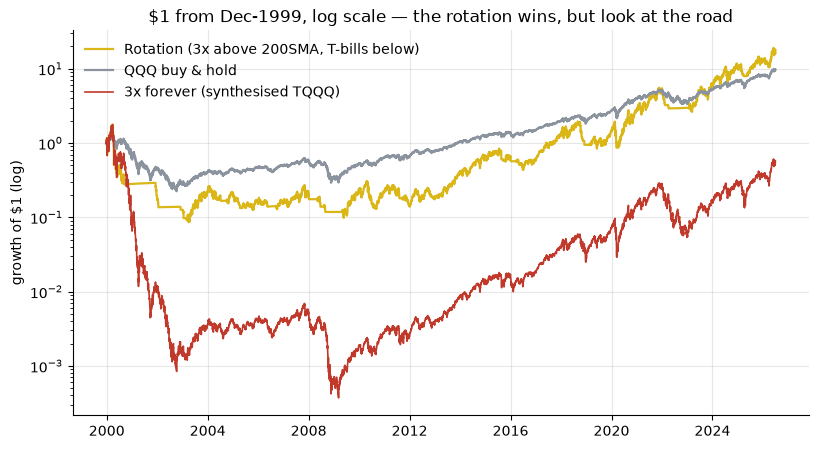

final multiples: rotation x17.81 | QQQ x9.77 | 3x-forever x0.57


In [2]:
def nav(r):
    return np.exp(np.log1p(r.dropna()).cumsum())

def dd(r):
    n = nav(r)
    return n / n.cummax() - 1.0
if HAVE_REAL:
    idx = ROT.index
    fig, ax = plt.subplots()
    ax.plot(nav(ROT), color=AMBER, lw=1.6, label="Rotation (3x above 200SMA, T-bills below)")
    ax.plot(nav(QQQ.reindex(idx)), color=GREY, lw=1.6, label="QQQ buy & hold")
    ax.plot(nav(SIM3.reindex(idx)), color=RED, lw=1.2, label="3x forever (synthesised TQQQ)")
    ax.set_yscale("log")
    ax.set_title("$1 from Dec-1999, log scale — the rotation wins, but look at the road")
    ax.set_ylabel("growth of $1 (log)")
    ax.legend(loc="upper left", frameon=False)
    plt.show()
    print("final multiples: rotation x%.2f | QQQ x%.2f | 3x-forever x%.2f"
          % (R["rot"][4], R["qqq"][4], R["sim3x"][4]))
else:
    print("cache missing - canonical numbers:", R["rot"], R["qqq"], R["sim3x"])


The rotation *does* finish ahead: **$1 → $17.8** vs **$9.8** for QQQ, while 3x-forever ends *below* $1 (the [melting-ice](../../100-melting-ice/) grave). That's the poster. Now the road:

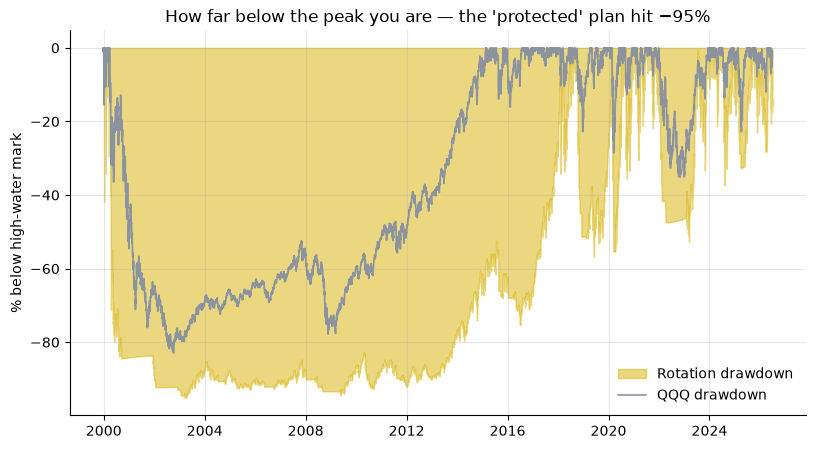

max drawdown: rotation -95.14% | QQQ -82.96% | 3x-forever -99.98%


In [3]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    ax.fill_between(dd(ROT).index, dd(ROT) * 100, 0, color=AMBER, alpha=.55,
                    label="Rotation drawdown")
    ax.plot(dd(QQQ.reindex(ROT.index)) * 100, color=GREY, lw=1.2, label="QQQ drawdown")
    ax.set_title("How far below the peak you are — the 'protected' plan hit −95%")
    ax.set_ylabel("% below high-water mark")
    ax.legend(loc="lower right", frameon=False)
    plt.show()
    print("max drawdown: rotation %.2f%% | QQQ %.2f%% | 3x-forever %.2f%%"
          % (R["rot"][3], R["qqq"][3], R["sim3x"][3]))


## Failure mode #1 — the parabolic-top trap (2000)

The rule exits when price closes below the 200-day average. But in 1999 QQQ went **vertical** — so by the March-2000 top, the 200-day average was **~35% below the price**. A 3x holder loses roughly **three times that** before the exit even fires. Then the 2000-02 chop whipsawed the rule **21 times**, each re-entry buying a bear rally, each exit selling the next leg down.

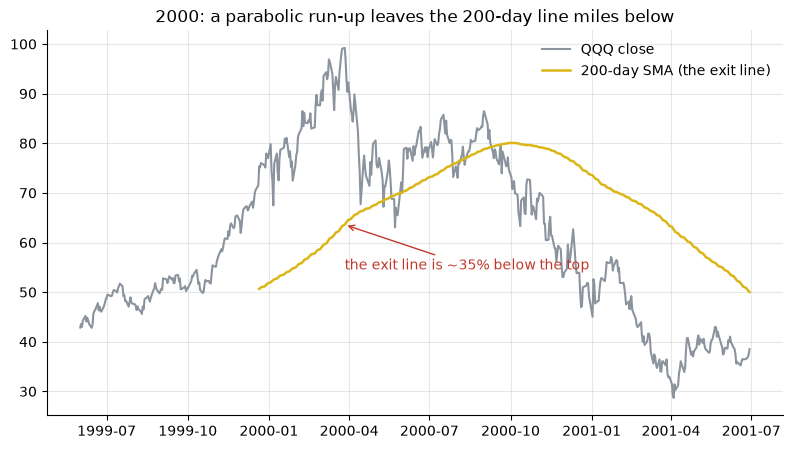

dot-com window: rotation -91.8% (dd -92.3%) vs QQQ -82.7% - with 21 whipsaw switches


In [4]:
if HAVE_REAL:
    px = PX["QQQ"].dropna().loc["1999-06-01":"2001-06-30"]
    sma = PX["QQQ"].dropna().rolling(200).mean().loc[px.index]
    fig, ax = plt.subplots()
    ax.plot(px, color=GREY, lw=1.5, label="QQQ close")
    ax.plot(sma, color=AMBER, lw=1.8, label="200-day SMA (the exit line)")
    gap_day = px.idxmax()
    ax.annotate("the exit line is ~35% below the top", xy=(gap_day, sma.loc[gap_day]),
                xytext=(gap_day, px.max() * 0.55),
                arrowprops=dict(arrowstyle="->", color=RED), color=RED)
    ax.set_title("2000: a parabolic run-up leaves the 200-day line miles below")
    ax.legend(frameon=False)
    plt.show()
    lbl, r1, d1, r2, d2, r3, d3, sw = R["subs"][0]
    print("dot-com window: rotation %+.1f%% (dd %+.1f%%) vs QQQ %+.1f%% - with %d whipsaw switches"
          % (r1, d1, r2, sw))


## Failure mode #2 — the V-crash whipsaw (COVID 2020)

The opposite kind of crash kills it too. COVID fell **too fast** for a 200-day line (you ride the 3x fund most of the way down) and recovered **too fast** (you're in cash while it V-bounces). Between Feb-19 and Apr-30 2020, plain QQQ was down just **−6.5%**; the "protected" rotation was down **−41.5%** — it *sold low and bought back high*.

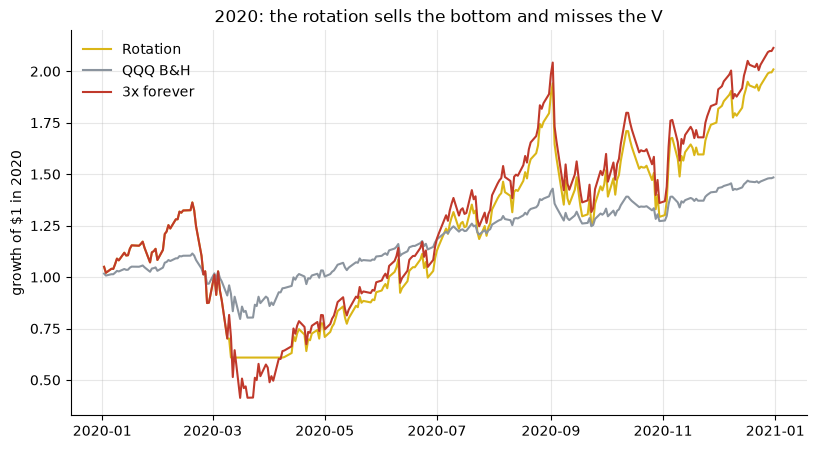

COVID crash window: rotation -41.5% | QQQ -6.5% | 3x -38.5%


In [5]:
if HAVE_REAL:
    win = slice("2020-01-01", "2020-12-31")
    fig, ax = plt.subplots()
    for r, c, lb in [(ROT.loc[win], AMBER, "Rotation"),
                     (QQQ.reindex(ROT.index).loc[win], GREY, "QQQ B&H"),
                     (SIM3.reindex(ROT.index).loc[win], RED, "3x forever")]:
        ax.plot(nav(r), color=c, lw=1.5, label=lb)
    ax.set_title("2020: the rotation sells the bottom and misses the V")
    ax.set_ylabel("growth of $1 in 2020")
    ax.legend(frameon=False)
    plt.show()
    lbl, r1, d1, r2, d2, r3, d3, sw = R["subs"][2]
    print("COVID crash window: rotation %+.1f%% | QQQ %+.1f%% | 3x %+.1f%%" % (r1, r2, r3))


## The one thing the line really does know

So is the 200-day line useless? No — it knows something real, just not what the pitch says. **Below the line, the market is about twice as violent** (annualised volatility ~40% vs ~20% above). That is a genuine, statistically overwhelming fact of the tape. But the *average next-day return* is the same on both sides. The line forecasts **weather, not direction** — which is why it can smooth the ride of a 1x portfolio ([Faber's rule](../../110-faber-timing/)) yet can't manufacture a return edge for a 3x one.

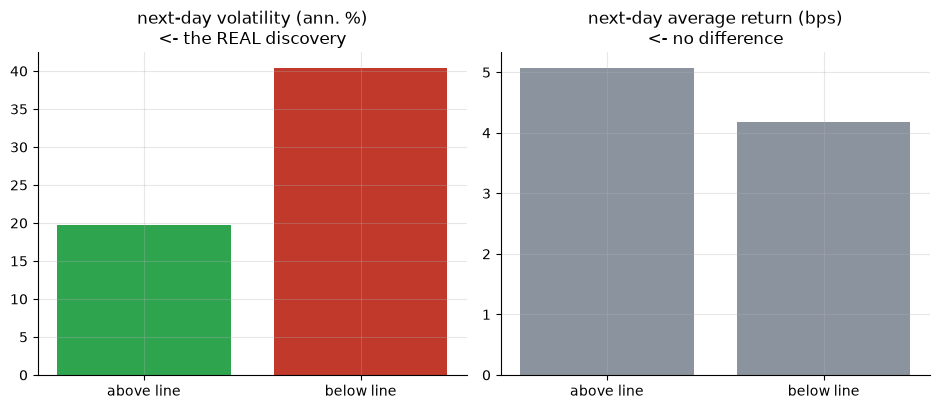

vol below/above = 2.05x | return difference: statistically nothing (t = +0.14)


In [6]:
if HAVE_REAL:
    c = st.sma_conditioning(QQQ, SIG)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
    axes[0].bar(["above line", "below line"], [c["vol_above_pct"], c["vol_below_pct"]],
                color=[GREEN, RED])
    axes[0].set_title("next-day volatility (ann. %)\n<- the REAL discovery")
    axes[1].bar(["above line", "below line"], [c["mean_above_bps"], c["mean_below_bps"]],
                color=[GREY, GREY])
    axes[1].set_title("next-day average return (bps)\n<- no difference")
    plt.tight_layout(); plt.show()
    print("vol below/above = %.2fx | return difference: statistically nothing (t = %+.2f)"
          % (R["cond"]["ratio"], R["cond"]["t_mean"]))


## The 2000 cohort's ledger — the third axis

The promise is *"3x upside without 3x crashes"*. Here is $10,000 placed at the worst possible moment (the 2000-03-24 peak) under the three plans:

| plan | worst point | back to $10k | 2026 value |
|---|--:|---|--:|
| **Rotation** | **$507** (−95%) | **2018** — 18.2 years | **$104,982** |
| QQQ buy & hold | $1,729 (−83%) | 2015 — 14.9 years | $75,338 |
| 3x forever | $2 (−99.98%) | never | $3,349 |

The rotation *eventually* wins the money race — **if** you are the investor who watches $10,000 become $507 and keeps following the spreadsheet for eighteen more years. A 95% loss **is** a 3x crash. The promise is **busted**; what survives is only the comparison with something even worse.

> 🔬 **For the quants:** the return edge never certifies — HAC *t* = +1.66 vs QQQ over the full tape, Welch *t* = +0.05 vs exposure-matched random timers; the vol channel is the only real signal (*t* = +13.79). The 2010+ window shows *t* = +2.52 vs QQQ — and *t* = −2.02 vs just holding TQQQ. Full gauntlet in [02_for_the_quants.ipynb](02_for_the_quants.ipynb).

## Verdict

**Signal: MIXED** — the 200-day line is a real *volatility* switch, not a return picker. **Tradability: MIRAGE** — costs don't hurt it; the −95% path and the fast-crash whipsaws do. **"The 2000 cohort survives": BUSTED** — they got exactly the crash they were promised they wouldn't.

*Research & education, not investment advice. Numbers: [docs/results.md](../docs/results.md), reproduced by `python examples/verify.py`.*